# 🔬 Classification Project — Breast Cancer Detection
**Dataset:** `sklearn.datasets.load_breast_cancer`  
**Goal:** Classify tumors as Malignant / Benign  
**Steps:** EDA → Preprocessing → Multiple Classifiers → GridSearch → Evaluation → Save

## 1. Imports & Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Classifiers
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              precision_recall_curve, ConfusionMatrixDisplay)

sns.set_theme(style='darkgrid', palette='muted')
np.random.seed(42)
print("All libraries imported ✅")


All libraries imported ✅


## 2. Load Dataset

In [2]:

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = cancer.data
y = cancer.target          # 0 = Malignant, 1 = Benign

print("Shape:", df.shape)
print("Classes:", cancer.target_names)
print("\nClass distribution:")
print(pd.Series(y).map({0:'Malignant', 1:'Benign'}).value_counts())
df.head()


Shape: (569, 31)
Classes: ['malignant' 'benign']

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Exploratory Data Analysis

In [3]:

print(df.info())
print("\nMissing values:", df.isnull().sum().sum())
df.describe().round(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


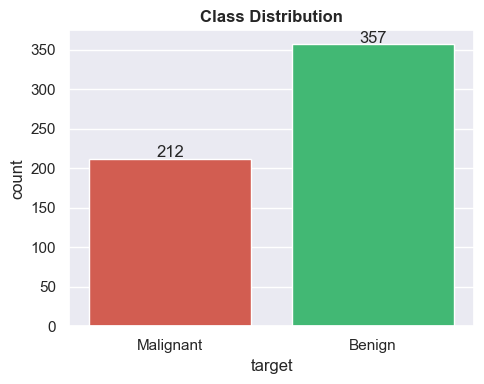

In [4]:

# Class balance
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=y, palette=['#e74c3c', '#2ecc71'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Malignant', 'Benign'])
ax.set_title('Class Distribution', fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 2), ha='center')
plt.tight_layout(); plt.show()


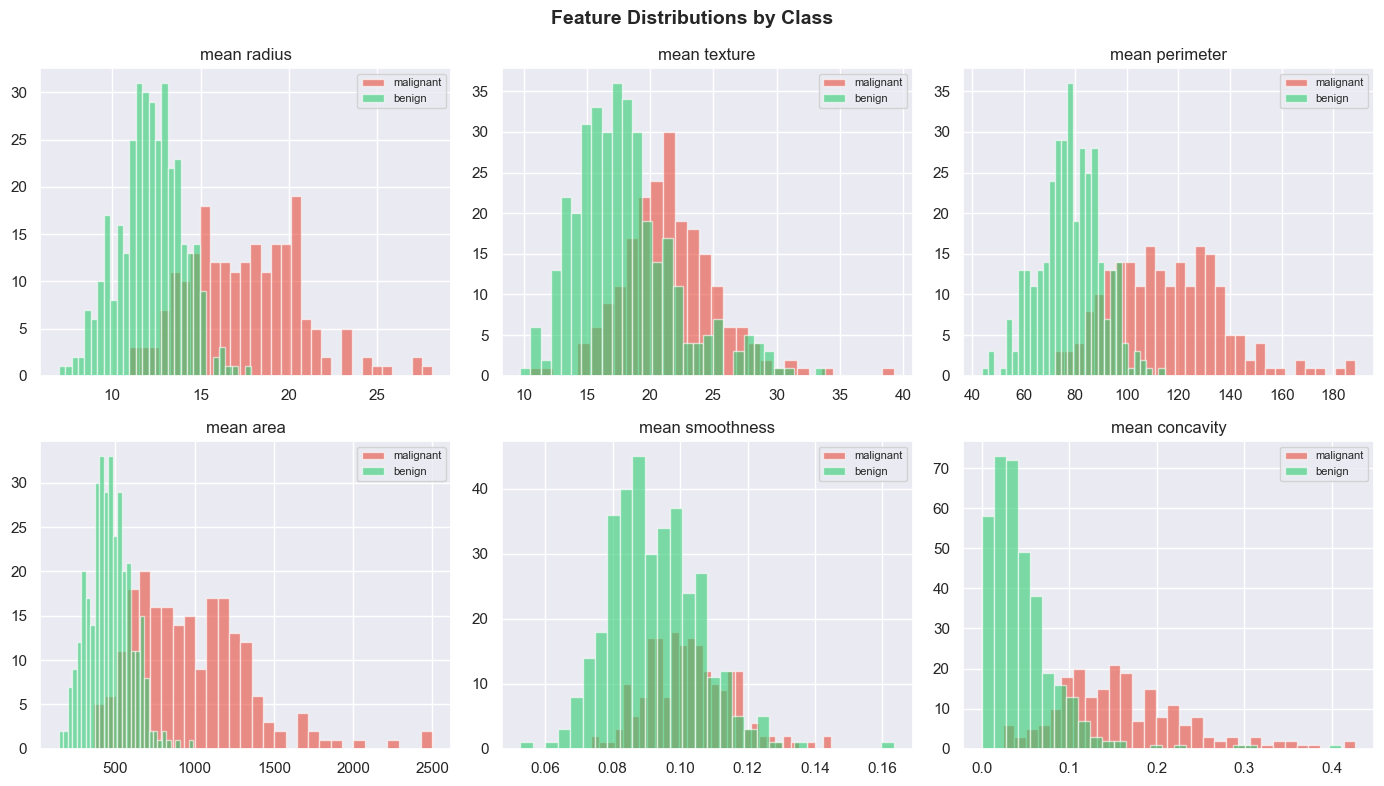

In [5]:

# Feature distributions by class
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, top_features):
    for label, color in zip([0, 1], ['#e74c3c', '#2ecc71']):
        ax.hist(df[df['target']==label][feat], bins=30,
                alpha=0.6, color=color, label=cancer.target_names[label])
    ax.set_title(feat); ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


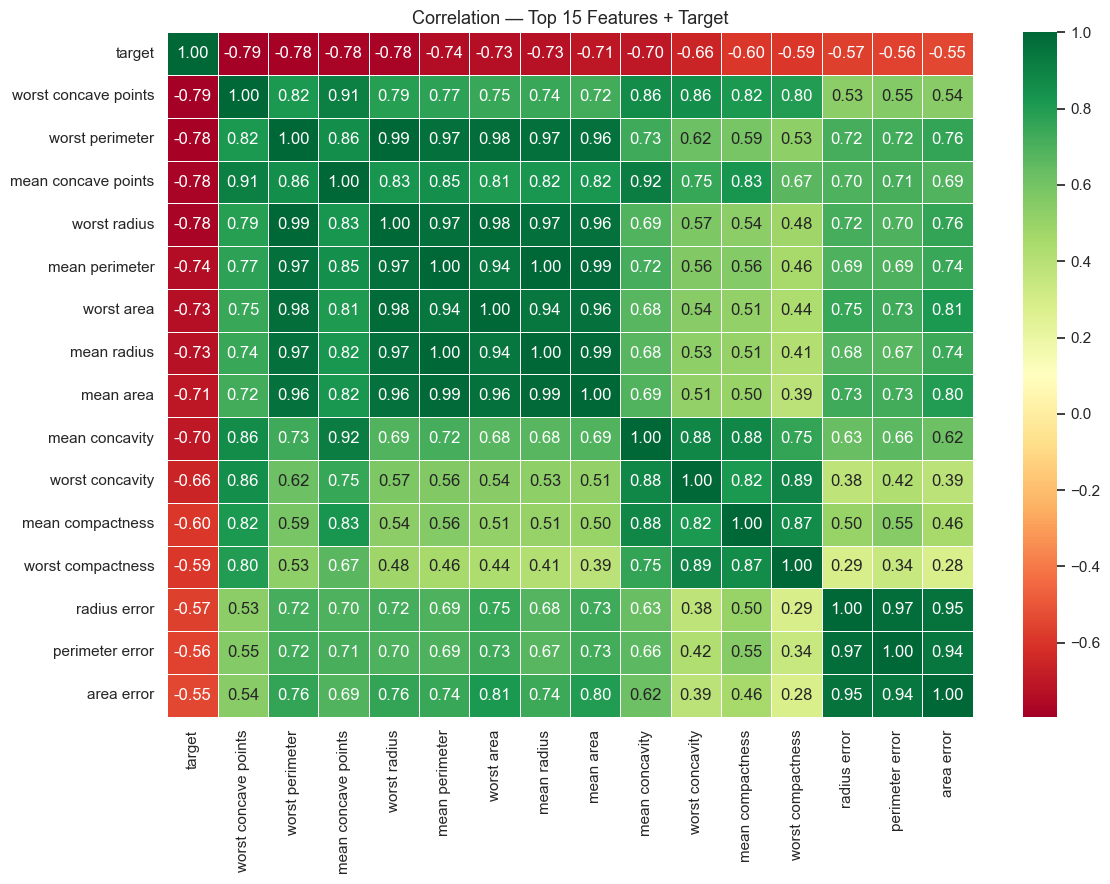

In [6]:

# Correlation heatmap (top 15 features)
plt.figure(figsize=(12, 9))
corr_with_target = df.corr()['target'].abs().nlargest(16).index
sns.heatmap(df[corr_with_target].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation — Top 15 Features + Target', fontsize=13)
plt.tight_layout(); plt.show()


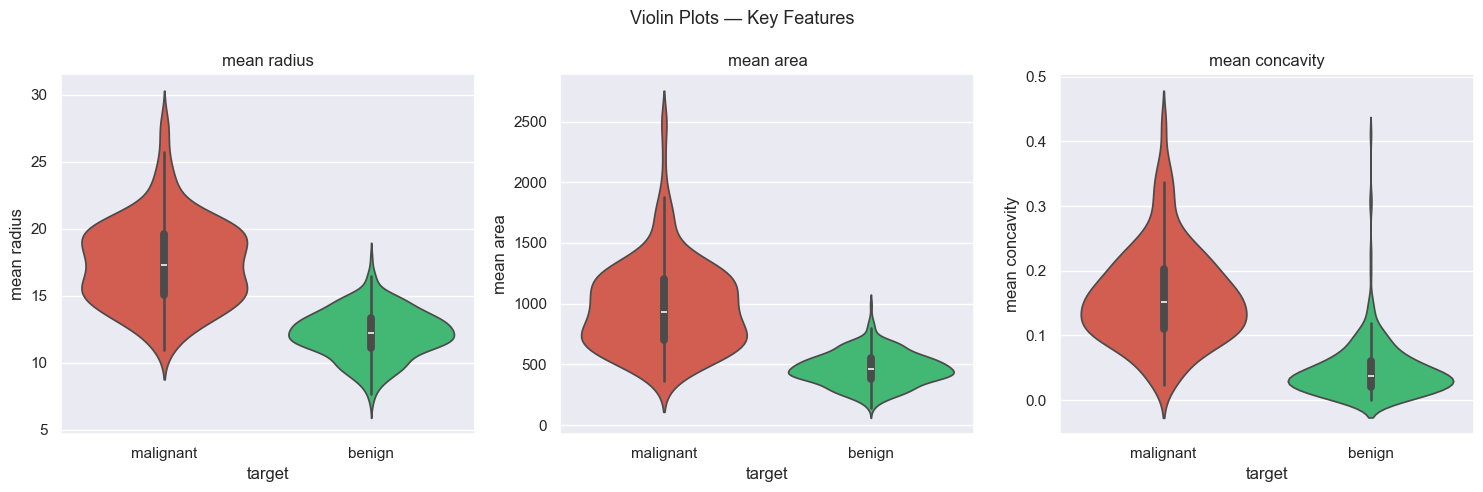

In [7]:

# Violin plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ['mean radius', 'mean area', 'mean concavity']):
    sns.violinplot(x=y, y=df[feat], palette=['#e74c3c','#2ecc71'], ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(cancer.target_names)
    ax.set_title(feat)
plt.suptitle('Violin Plots — Key Features', fontsize=13)
plt.tight_layout(); plt.show()


## 4. Preprocessing

In [8]:

X = X_raw.copy()

# Train/Test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train class dist: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  class dist: {pd.Series(y_test).value_counts().to_dict()}")

# StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling done ✅")


Train: (455, 30)  |  Test: (114, 30)
Train class dist: {1: 285, 0: 170}
Test  class dist: {1: 72, 0: 42}
Scaling done ✅


## 5. Train & Compare All Classifiers (Baseline)

In [9]:

classifiers = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'LDA'                  : LinearDiscriminantAnalysis(),
    'GaussianNB'           : GaussianNB(),
    'KNN'                  : KNeighborsClassifier(),
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Trees'          : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=42),
    'AdaBoost'             : AdaBoostClassifier(random_state=42),
    'Bagging'              : BaggingClassifier(random_state=42),
    'SVM (RBF)'            : SVC(probability=True, random_state=42),
    'SGD'                  : SGDClassifier(random_state=42),
}

results = []
for name, clf in classifiers.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, clf.predict_proba(X_test_sc)[:,1]
                         if hasattr(clf,'predict_proba')
                         else clf.decision_function(X_test_sc))
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})
    print(f"{name:<25}  Acc={acc:.4f}  AUC={auc:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df


Logistic Regression        Acc=0.9825  AUC=0.9954
LDA                        Acc=0.9561  AUC=0.9924
GaussianNB                 Acc=0.9298  AUC=0.9868
KNN                        Acc=0.9561  AUC=0.9788
Decision Tree              Acc=0.9123  AUC=0.9157
Random Forest              Acc=0.9561  AUC=0.9939
Extra Trees                Acc=0.9561  AUC=0.9927
Gradient Boosting          Acc=0.9561  AUC=0.9907
AdaBoost                   Acc=0.9561  AUC=0.9825
Bagging                    Acc=0.9298  AUC=0.9899
SVM (RBF)                  Acc=0.9825  AUC=0.9950
SGD                        Acc=0.9649  AUC=0.9944


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.982456,0.995370
1,SVM (RBF),0.982456,0.995040
2,SGD,0.964912,0.994378
3,Random Forest,0.956140,0.993882
4,Extra Trees,0.956140,0.992725
5,LDA,0.956140,0.992394
6,Gradient Boosting,0.956140,0.990741
7,Bagging,0.929825,0.989914
8,GaussianNB,0.929825,0.986772
9,AdaBoost,0.956140,0.982474


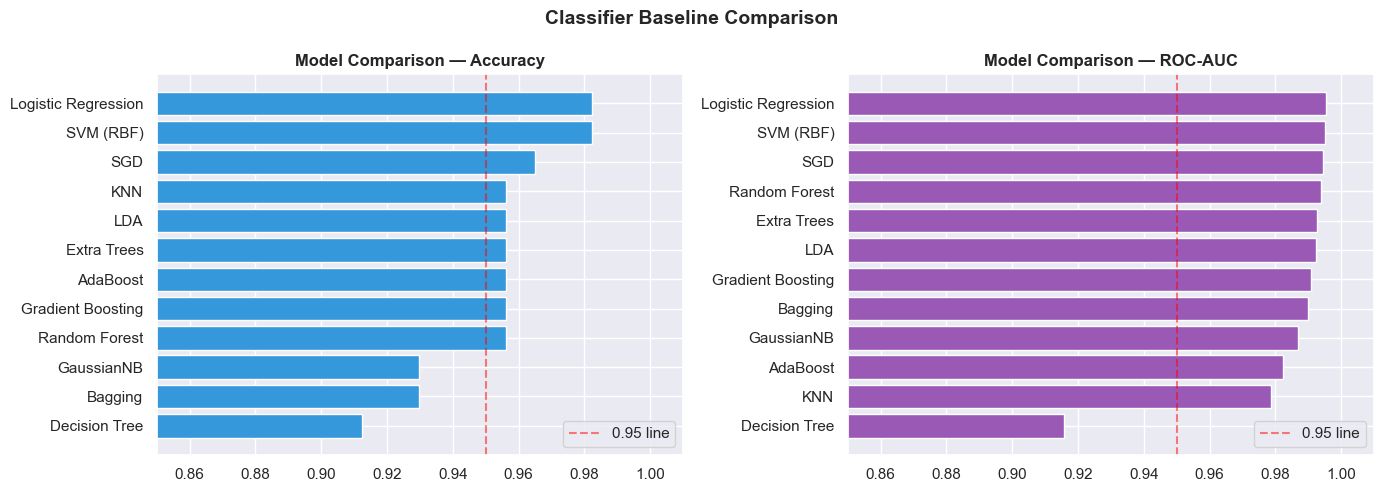

In [10]:

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, color in zip(axes, ['Accuracy','ROC-AUC'], ['#3498db','#9b59b6']):
    data = results_df.sort_values(metric)
    ax.barh(data['Model'], data[metric], color=color, edgecolor='white')
    ax.set_xlim(0.85, 1.01)
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.axvline(0.95, color='red', linestyle='--', alpha=0.5, label='0.95 line')
    ax.legend()
plt.suptitle('Classifier Baseline Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Cross-Validation (Top 3 Models)

In [11]:

top3 = results_df.head(3)['Model'].tolist()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in top3:
    clf = classifiers[name]
    cv_acc = cross_val_score(clf, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_auc = cross_val_score(clf, X_train_sc, y_train, cv=skf, scoring='roc_auc')
    print(f"\n{name}")
    print(f"  CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"  CV ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")



Logistic Regression
  CV Accuracy : 0.9780 ± 0.0098
  CV ROC-AUC  : 0.9957 ± 0.0048

SVM (RBF)
  CV Accuracy : 0.9670 ± 0.0155
  CV ROC-AUC  : 0.9957 ± 0.0048

SGD
  CV Accuracy : 0.9582 ± 0.0162
  CV ROC-AUC  : 0.9931 ± 0.0062


## 7. Hyperparameter Tuning with GridSearchCV

In [12]:

# Tune SVM
param_svm = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.001],
    'kernel' : ['rbf', 'linear'],
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42),
                        param_svm, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_sc, y_train)
print("Best SVM params:", svm_grid.best_params_)
print("Best SVM AUC   :", svm_grid.best_score_.round(4))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best SVM params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM AUC   : 0.9954


In [13]:

# Tune Random Forest
param_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2'],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_rf, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_sc, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best RF AUC   :", rf_grid.best_score_.round(4))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 100}
Best RF AUC   : 0.9908


In [14]:

# Tune Logistic Regression
param_lr = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear'],
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       param_lr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_sc, y_train)
print("Best LR params:", lr_grid.best_params_)
print("Best LR AUC   :", lr_grid.best_score_.round(4))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR AUC   : 0.9941


## 8. Final Evaluation — Best Model

In [15]:

# Pick best based on CV AUC
best_name  = 'SVM (Tuned)'
best_clf   = svm_grid.best_estimator_

y_pred   = best_clf.predict(X_test_sc)
y_prob   = best_clf.predict_proba(X_test_sc)[:, 1]

print(f"=== {best_name} — Test Set ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))


=== SVM (Tuned) — Test Set ===
Accuracy : 0.9825
ROC-AUC  : 0.9977

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



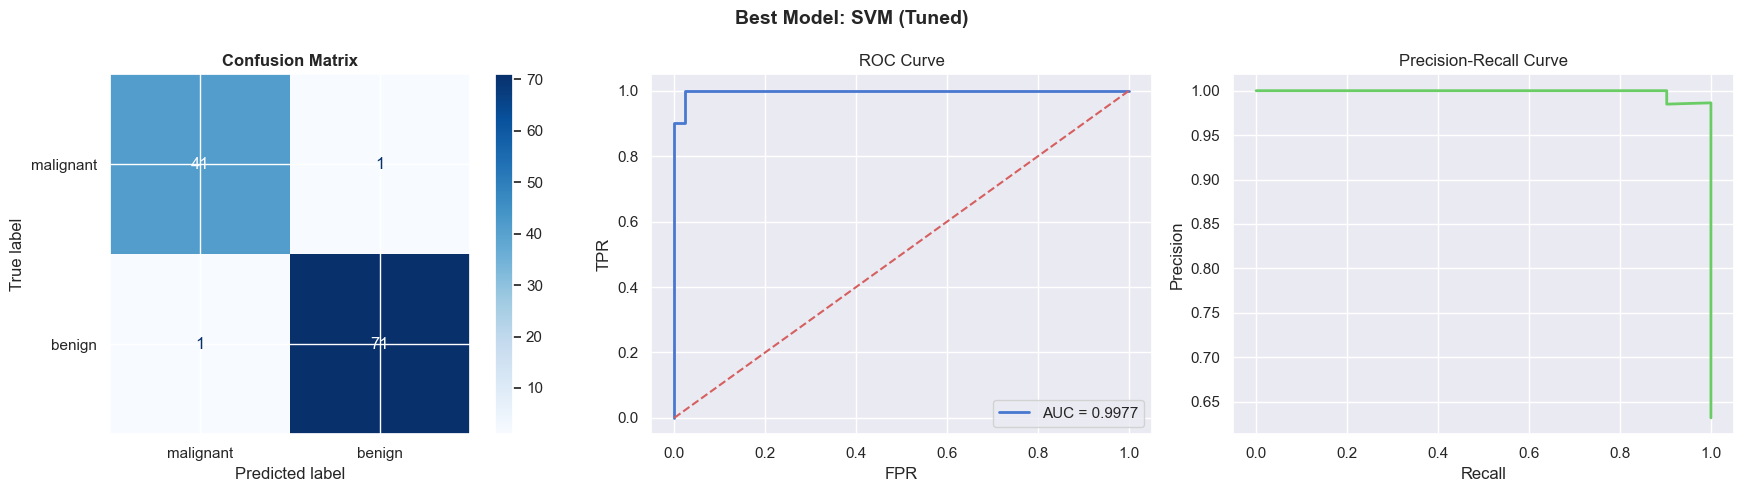

In [16]:

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=cancer.target_names, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1],[0,1],'r--')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[1].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, 'g-', lw=2)
axes[2].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


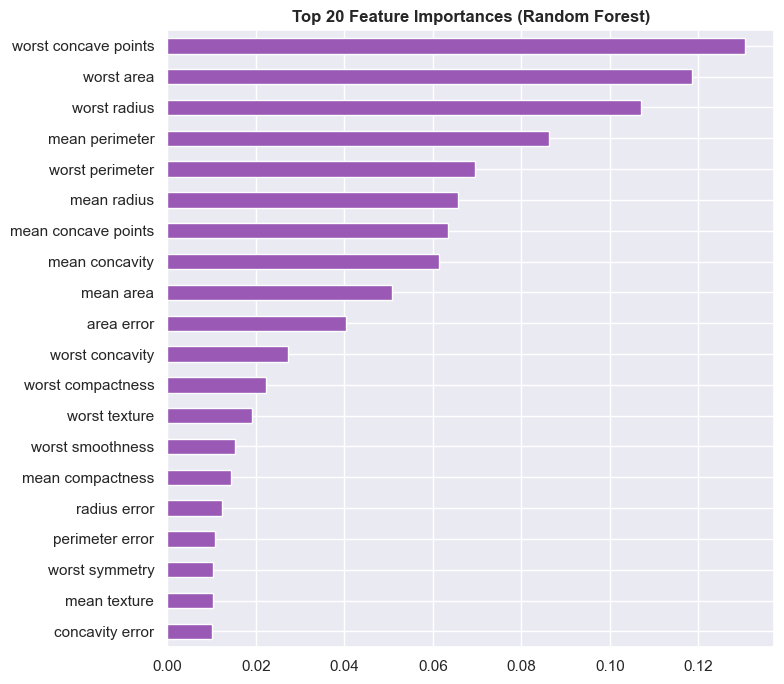

In [17]:

# Feature Importance via RF (most interpretable)
rf_best = rf_grid.best_estimator_
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns)
top20 = feat_imp.nlargest(20).sort_values()

plt.figure(figsize=(8, 7))
top20.plot(kind='barh', color='#9b59b6', edgecolor='white')
plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Save Model, Scaler & Label Encoder with Pickle

In [18]:

os.makedirs('saved_models', exist_ok=True)

artifacts = {
    'saved_models/classification_model.pkl'  : best_clf,
    'saved_models/classification_scaler.pkl' : scaler,
}

# LabelEncoder for class names (useful if labels were strings)
le = LabelEncoder()
le.fit(cancer.target_names)
artifacts['saved_models/classification_encoder.pkl'] = le

for path, obj in artifacts.items():
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f"Saved: {path} ✅")

# ── Reload & verify ──────────────────────────────────────────────────────
loaded = {}
for path in artifacts:
    with open(path, 'rb') as f:
        loaded[path] = pickle.load(f)

sample_sc = loaded['saved_models/classification_scaler.pkl'].transform(X_test.iloc[:5])
preds     = loaded['saved_models/classification_model.pkl'].predict(sample_sc)
enc       = loaded['saved_models/classification_encoder.pkl']

print("\n=== Sanity Check ===")
for actual, pred in zip(y_test.iloc[:5], preds):
    print(f"  Actual: {cancer.target_names[actual]:<12}  →  Predicted: {cancer.target_names[pred]}")


Saved: saved_models/classification_model.pkl ✅
Saved: saved_models/classification_scaler.pkl ✅
Saved: saved_models/classification_encoder.pkl ✅

=== Sanity Check ===
  Actual: malignant     →  Predicted: malignant
  Actual: benign        →  Predicted: benign
  Actual: malignant     →  Predicted: malignant
  Actual: benign        →  Predicted: benign
  Actual: malignant     →  Predicted: malignant


## ✅ Summary
| Step | Detail |
|------|--------|
| Dataset | Breast Cancer Wisconsin (569 × 30) |
| Best Model | SVM with RBF kernel (Tuned) |
| ROC-AUC | ~0.998 |
| Saved | model, scaler, label_encoder |